# Subset Final Recommender Notebook

## Goal
Take the strongest models from `subset-05-ml-prediction.ipynb`, tune them more
carefully, validate them with stronger cross-validation, lock-in a single
production-ready model per resource, expose the features that drive each
recommendation, and finally show a deployment-style recommendation that a
developer would see before submitting a job.

## Scope (mapped to the issue)
1. **Hyperparameter tuning** of the strongest Subset-05 candidates
   (Random Forest and XGBoost for both CPU and memory).
2. **Cross-validation** with `TimeSeriesSplit` and `GroupKFold` (grouped on
   `recurrence_key`) — report mean and variance across folds.
3. **Final model lock-in** for CPU and memory (refit on full training data).
4. **Feature importance / explainability** charts for both models.
5. **Developer-facing recommendation simulation** that turns a single job's
   metadata + history into a CPU/memory recommendation, a confidence tier,
   and an expected violation-risk label — i.e. what TraceAdvisor would show
   the user.

## Inputs (produced by earlier notebooks)
- `job_metrics_train_v0.parquet`
- `job_metrics_val_with_baselines_v0.parquet`
- `job_metrics_test_with_baselines_v0.parquet`
- `job_profiles_train_only_v0.parquet`

## Outputs
- `reports/eval/subset/tables/ml_tuning_summary_v0.csv`
- `reports/eval/subset/tables/ml_cv_summary_v0.csv`
- `reports/eval/subset/tables/final_recommender_test_v0.csv`
- `reports/eval/subset/figures_ml/feature_importance_cpu.png`
- `reports/eval/subset/figures_ml/feature_importance_mem.png`
- `data/processed/job_metrics_test_with_final_recommendations_v0.parquet`


## 1. Setup and Paths

In [1]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import (
    GridSearchCV,
    HalvingGridSearchCV,
    TimeSeriesSplit,
    GroupKFold,
    cross_val_score,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    REPO_ROOT = Path("/content/drive/Shareddrives/CMPE 295A_B/subset")
else:
    REPO_ROOT = Path.cwd()
    while REPO_ROOT.name != "masters-project" and REPO_ROOT.parent != REPO_ROOT:
        REPO_ROOT = REPO_ROOT.parent
    if REPO_ROOT.name != "masters-project":
        raise RuntimeError("Could not find repo root folder named 'masters-project'.")

DATA_PROCESSED = REPO_ROOT / "data" / "processed"
REPORTS_DIR = REPO_ROOT / "reports" / "eval" / "subset"
TABLE_DIR = REPORTS_DIR / "tables"
FIG_ML_DIR = REPORTS_DIR / "figures_ml"

for d in (TABLE_DIR, FIG_ML_DIR):
    d.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_PROCESSED / "job_metrics_train_v0.parquet"
VAL_PATH = DATA_PROCESSED / "job_metrics_val_with_baselines_v0.parquet"
TEST_PATH = DATA_PROCESSED / "job_metrics_test_with_baselines_v0.parquet"
# Point-in-time training profiles generated in Notebook 4
TRAIN_PROFILES_PATH = DATA_PROCESSED / "job_profiles_train_history_v1.parquet"

print("Repo root:", REPO_ROOT)
for p in (TRAIN_PATH, VAL_PATH, TEST_PATH, TRAIN_PROFILES_PATH):
    print(f"  {p.name:50s} exists={p.exists()}")


Repo root: /Users/sofiasilva/Masters-project/masters-project
  job_metrics_train_v0.parquet                       exists=True
  job_metrics_val_with_baselines_v0.parquet          exists=True
  job_metrics_test_with_baselines_v0.parquet         exists=True
  job_profiles_train_history_v1.parquet              exists=True


## 2. Load data and rebuild the feature matrix

We follow the same feature-engineering recipe as Subset 5 so that this
notebook is a *strict extension* of the earlier results — i.e. tuning and
cross-validation happen on the exact same inputs.


In [2]:
# Load train / validation / test datasets
train_df = pd.read_parquet(TRAIN_PATH)
val_df = pd.read_parquet(VAL_PATH)
test_df = pd.read_parquet(TEST_PATH)

# Load point-in-time historical profiles for training
train_profiles = pd.read_parquet(TRAIN_PROFILES_PATH)

profile_cols = [
    "recurrence_key",
    "start_time",
]

if (
    "execution_id" in train_df.columns
    and "execution_id" in train_profiles.columns
):
    profile_cols.append("execution_id")

profile_cols += [
    "run_count",
    "mean_peak_cpu",
    "std_peak_cpu",
    "mean_peak_mem",
    "std_peak_mem",
    "mean_duration",
    "cv_cpu",
    "cv_mem",
    "stability",
    "is_recurring",
    "confidence_tier",
    "resource_profile",
    "duration_profile",
    "recurrence_profile",
    "stability_profile",
    "p90_cpu",
    "p95_cpu",
    "p99_cpu",
    "p90_mem",
    "p95_mem",
    "p99_mem",
]

train_profiles = train_profiles[profile_cols].copy()

rename_map = {
    "run_count": "hist_run_count",
    "mean_peak_cpu": "hist_mean_peak_cpu",
    "std_peak_cpu": "hist_std_peak_cpu",
    "mean_peak_mem": "hist_mean_peak_mem",
    "std_peak_mem": "hist_std_peak_mem",
    "mean_duration": "hist_mean_duration",
    "cv_cpu": "hist_cv_cpu",
    "cv_mem": "hist_cv_mem",
    "stability": "hist_stability",
    "is_recurring": "hist_is_recurring",
    "confidence_tier": "hist_confidence_tier",
    "resource_profile": "hist_resource_profile",
    "duration_profile": "hist_duration_profile",
    "recurrence_profile": "hist_recurrence_profile",
    "stability_profile": "hist_stability_profile",
    "p90_cpu": "hist_p90_cpu",
    "p95_cpu": "hist_p95_cpu",
    "p99_cpu": "hist_p99_cpu",
    "p90_mem": "hist_p90_mem",
    "p95_mem": "hist_p95_mem",
    "p99_mem": "hist_p99_mem",
}

train_profiles = train_profiles.rename(columns=rename_map)

# Match each training execution with its own point-in-time history
train_df["start_time"] = pd.to_datetime(
    train_df["start_time"], errors="coerce"
)

train_profiles["start_time"] = pd.to_datetime(
    train_profiles["start_time"], errors="coerce"
)

join_cols = ["recurrence_key", "start_time"]

if (
    "execution_id" in train_df.columns
    and "execution_id" in train_profiles.columns
):
    join_cols.append("execution_id")

original_train_rows = len(train_df)

train_df = train_df.merge(
    train_profiles,
    on=join_cols,
    how="left",
    validate="one_to_one"
)

assert len(train_df) == original_train_rows

print(
    "Train:", train_df.shape,
    " Val:", val_df.shape,
    " Test:", test_df.shape
)


Train: (50220, 34)  Val: (10762, 48)  Test: (10762, 48)


In [3]:
TARGET_CPU = "peak_cpu"
TARGET_MEM = "peak_mem_gb"

feature_cols = [
    # Resource requests known before execution
    "req_cpu",
    "req_mem_gb",

    # Point-in-time recurrence/history
    "hist_run_count",
    "hist_is_recurring",
    "hist_mean_duration",

    # CPU history
    "hist_mean_peak_cpu",
    "hist_std_peak_cpu",
    "hist_cv_cpu",
    "hist_p90_cpu",
    "hist_p95_cpu",
    "hist_p99_cpu",

    # Memory history
    "hist_mean_peak_mem",
    "hist_std_peak_mem",
    "hist_cv_mem",
    "hist_p90_mem",
    "hist_p95_mem",
    "hist_p99_mem",

    # Historical categorical/profile features
    "hist_confidence_tier",
    "hist_resource_profile",
    "hist_duration_profile",
    "hist_recurrence_profile",
    "hist_stability_profile",
    "hist_stability",
]

# Only keep features available in every split
feature_cols = [
    c for c in feature_cols
    if c in train_df.columns
    and c in val_df.columns
    and c in test_df.columns
]

print(f"Using {len(feature_cols)} features")


def prepare_xy(df, target_col):
    X = df[feature_cols].copy()
    y = df[target_col].copy()

    X = pd.get_dummies(X, dummy_na=True)
    X = X.fillna(0)

    return X, y


def build_aligned(target_col):
    Xtr, ytr = prepare_xy(train_df, target_col)
    Xva, yva = prepare_xy(val_df, target_col)
    Xte, yte = prepare_xy(test_df, target_col)

    # Training data defines the feature schema
    train_cols = Xtr.columns

    Xva = Xva.reindex(columns=train_cols, fill_value=0)
    Xte = Xte.reindex(columns=train_cols, fill_value=0)

    return Xtr, ytr, Xva, yva, Xte, yte


X_train_cpu, y_train_cpu, X_val_cpu, y_val_cpu, X_test_cpu, y_test_cpu = (
    build_aligned(TARGET_CPU)
)

X_train_mem, y_train_mem, X_val_mem, y_val_mem, X_test_mem, y_test_mem = (
    build_aligned(TARGET_MEM)
)

print(
    "CPU matrices :",
    X_train_cpu.shape,
    X_val_cpu.shape,
    X_test_cpu.shape,
)

print(
    "MEM matrices :",
    X_train_mem.shape,
    X_val_mem.shape,
    X_test_mem.shape,
)


Using 23 features
CPU matrices : (50220, 39) (10762, 39) (10762, 39)
MEM matrices : (50220, 39) (10762, 39) (10762, 39)


## 3. Hyperparameter tuning

Random Forest and XGBoost are tuned for both CPU and memory prediction.
Model selection is based on validation RMSE only. The test split remains
untouched until the final models and recommendation logic are locked.


In [4]:
def neg_rmse(y_true, y_pred):
    return -np.sqrt(mean_squared_error(y_true, y_pred))


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


# Tune the same candidate model families for both CPU and memory.
# Tree depth is capped to keep Random Forest practical at this scale.
rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 16],
    "min_samples_leaf": [5],
}

xgb_grid = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

# Preserve chronological order during cross-validation
time_cv = TimeSeriesSplit(n_splits=3)


def tune_grid(model, grid, X, y, label):
    gs = GridSearchCV(
        model,
        grid,
        scoring="neg_root_mean_squared_error",
        cv=time_cv,
        n_jobs=-1,
        verbose=1,
    )
    gs.fit(X, y)

    print(f"[{label}] best RMSE (CV) = {-gs.best_score_:.4f}")
    print(f"[{label}] best params    = {gs.best_params_}")

    return gs


def tune_halving(model, grid, X, y, label):
    gs = HalvingGridSearchCV(
        model,
        grid,
        scoring="neg_root_mean_squared_error",
        cv=time_cv,
        n_jobs=-1,
        verbose=1,
        factor=3,
        resource="n_samples",
        random_state=42,
    )
    gs.fit(X, y)

    print(f"[{label}] best RMSE (CV) = {-gs.best_score_:.4f}")
    print(f"[{label}] best params    = {gs.best_params_}")

    return gs


# CPU models
cpu_rf_tuned = tune_grid(
    RandomForestRegressor(random_state=42, n_jobs=1),
    rf_grid,
    X_train_cpu,
    y_train_cpu,
    "CPU / RandomForest",
)

cpu_xgb_tuned = tune_halving(
    XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1,
        verbosity=0,
        tree_method="hist",
    ),
    xgb_grid,
    X_train_cpu,
    y_train_cpu,
    "CPU / XGBoost",
)


# Memory models
mem_rf_tuned = tune_grid(
    RandomForestRegressor(random_state=42, n_jobs=1),
    rf_grid,
    X_train_mem,
    y_train_mem,
    "MEM / RandomForest",
)

mem_xgb_tuned = tune_halving(
    XGBRegressor(
        objective="reg:squarederror",
        random_state=42,
        n_jobs=1,
        verbosity=0,
        tree_method="hist",
    ),
    xgb_grid,
    X_train_mem,
    y_train_mem,
    "MEM / XGBoost",
)

Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CPU / RandomForest] best RMSE (CV) = 0.0407
[CPU / RandomForest] best params    = {'max_depth': 16, 'min_samples_leaf': 5, 'n_estimators': 100}
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 1860
max_resources_: 50220
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 32
n_resources: 1860
Fitting 3 folds for each of 32 candidates, totalling 96 fits
----------
iter: 1
n_candidates: 11
n_resources: 5580
Fitting 3 folds for each of 11 candidates, totalling 33 fits
----------
iter: 2
n_candidates: 4
n_resources: 16740
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 3
n_candidates: 2
n_resources: 50220
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CPU / XGBoost] best RMSE (CV) = 0.0449
[CPU / XGBoost] best params    = {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}
Fitting 3 fo

In [5]:
def score_on(model, X, y):
    pred = model.predict(X)
    return {
        "mae": float(mean_absolute_error(y, pred)),
        "rmse": rmse(y, pred),
        "r2": float(r2_score(y, pred)),
    }


# Candidate models are compared using validation only.
# Test remains untouched until final model selection is complete.

tuning_rows = []

for name, gs, X_va, y_va, resource in [
    (
        "RandomForest",
        cpu_rf_tuned,
        X_val_cpu,
        y_val_cpu,
        "cpu"
    ),
    (
        "XGBoost",
        cpu_xgb_tuned,
        X_val_cpu,
        y_val_cpu,
        "cpu"
    ),
    (
        "RandomForest",
        mem_rf_tuned,
        X_val_mem,
        y_val_mem,
        "mem"
    ),
    (
        "XGBoost",
        mem_xgb_tuned,
        X_val_mem,
        y_val_mem,
        "mem"
    ),
]:
    val_scores = score_on(
        gs.best_estimator_,
        X_va,
        y_va
    )

    tuning_rows.append({
        "resource": resource,
        "model": name,
        "split": "val",
        "best_params": json.dumps(gs.best_params_),
        **val_scores,
    })


tuning_df = pd.DataFrame(tuning_rows)

tuning_df.to_csv(
    TABLE_DIR / "ml_tuning_summary_v0.csv",
    index=False,
    float_format="%.6f"
)

display(
    tuning_df.sort_values(
        ["resource", "rmse"]
    )
)


,resource,model,split,best_params,mae,rmse,r2
1,cpu,XGBoost,val,"{""colsample_bytree"": 1.0, ""learning_rate"": 0.0...",0.017724,0.033787,0.540862
0,cpu,RandomForest,val,"{""max_depth"": 16, ""min_samples_leaf"": 5, ""n_es...",0.019167,0.039151,0.383513
2,mem,RandomForest,val,"{""max_depth"": 10, ""min_samples_leaf"": 5, ""n_es...",0.001842,0.005168,0.699408
3,mem,XGBoost,val,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.0...",0.002279,0.005640,0.641958


## 4. Cross-validation: stronger than a single train/val split

We score the tuned models with two complementary CV strategies on the
training split:

- **`TimeSeriesSplit`** — respects temporal order, so the model is always
  evaluated on rows that come *after* its training fold. This tests
  generalization to later executions.

- **`GroupKFold`** grouped by `recurrence_key` — guarantees that a recurrence
  group does not appear in both train and validation within the same fold.
  This is a separate diagnostic for generalization to unseen recurrence groups.
  
We report mean and standard deviation of RMSE across folds — variance
matters as much as the mean for production reliability.


In [6]:

def cv_report(model, X, y, groups, label):
    rows = []

    # 1. Chronological generalization:
    # Can the model predict later executions from earlier executions?
    tss = TimeSeriesSplit(n_splits=5)

    ts_scores = -cross_val_score(
        model,
        X,
        y,
        cv=tss,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )

    rows.append({
        "model": label,
        "cv": "TimeSeriesSplit(5)",
        "mean_rmse": float(ts_scores.mean()),
        "std_rmse": float(ts_scores.std()),
        "min_rmse": float(ts_scores.min()),
        "max_rmse": float(ts_scores.max()),
    })

    # 2. Recurrence-group generalization diagnostic:
    # No recurrence_key appears in both sides of a fold.
    gkf = GroupKFold(n_splits=5)

    group_scores = -cross_val_score(
        model,
        X,
        y,
        groups=groups,
        cv=gkf,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1,
    )

    rows.append({
        "model": label,
        "cv": "GroupKFold(5)",
        "mean_rmse": float(group_scores.mean()),
        "std_rmse": float(group_scores.std()),
        "min_rmse": float(group_scores.min()),
        "max_rmse": float(group_scores.max()),
    })

    return rows


groups_train = train_df["recurrence_key"]

cv_rows = []

cv_rows += cv_report(
    cpu_rf_tuned.best_estimator_,
    X_train_cpu,
    y_train_cpu,
    groups_train,
    "CPU / RandomForest (tuned)"
)

cv_rows += cv_report(
    cpu_xgb_tuned.best_estimator_,
    X_train_cpu,
    y_train_cpu,
    groups_train,
    "CPU / XGBoost (tuned)"
)

cv_rows += cv_report(
    mem_rf_tuned.best_estimator_,
    X_train_mem,
    y_train_mem,
    groups_train,
    "MEM / RandomForest (tuned)"
)

cv_rows += cv_report(
    mem_xgb_tuned.best_estimator_,
    X_train_mem,
    y_train_mem,
    groups_train,
    "MEM / XGBoost (tuned)"
)

cv_df = pd.DataFrame(cv_rows)

cv_df.to_csv(
    TABLE_DIR / "ml_cv_summary_v0.csv",
    index=False,
    float_format="%.6f"
)

display(cv_df)


,model,cv,mean_rmse,std_rmse,min_rmse,max_rmse
0,CPU / RandomForest (tuned),TimeSeriesSplit(5),0.045027,0.014681,0.029644,0.072555
1,CPU / RandomForest (tuned),GroupKFold(5),0.047993,0.012693,0.035652,0.072352
2,CPU / XGBoost (tuned),TimeSeriesSplit(5),0.047842,0.020422,0.033947,0.088152
3,CPU / XGBoost (tuned),GroupKFold(5),0.046365,0.011058,0.036343,0.067893
4,MEM / RandomForest (tuned),TimeSeriesSplit(5),0.013127,0.007518,0.007099,0.026895
5,MEM / RandomForest (tuned),GroupKFold(5),0.012504,0.007010,0.005768,0.025351
6,MEM / XGBoost (tuned),TimeSeriesSplit(5),0.011155,0.005058,0.006865,0.020551
7,MEM / XGBoost (tuned),GroupKFold(5),0.013434,0.006815,0.007482,0.025560


## 5. Final model lock-in

Pick the best tuned model per resource (lowest validation RMSE) and refit on
the full training set. These two refit estimators are the *production
recommenders* used for everything below.


In [7]:
# Select final models using validation only

val_only = tuning_df[tuning_df["split"] == "val"]

cpu_pick = (
    val_only[val_only["resource"] == "cpu"]
    .sort_values("rmse")
    .iloc[0]
)

mem_pick = (
    val_only[val_only["resource"] == "mem"]
    .sort_values("rmse")
    .iloc[0]
)

print(f"Final CPU model: {cpu_pick['model']}  val RMSE={cpu_pick['rmse']:.4f}")
print(f"  params: {cpu_pick['best_params']}")

print(f"Final MEM model: {mem_pick['model']}  val RMSE={mem_pick['rmse']:.4f}")
print(f"  params: {mem_pick['best_params']}")

cpu_estimators = {
    "RandomForest": cpu_rf_tuned.best_estimator_,
    "XGBoost": cpu_xgb_tuned.best_estimator_,
}

mem_estimators = {
    "RandomForest": mem_rf_tuned.best_estimator_,
    "XGBoost": mem_xgb_tuned.best_estimator_,
}

final_cpu_model = cpu_estimators[cpu_pick["model"]]
final_mem_model = mem_estimators[mem_pick["model"]]

# Refit the locked models on the full training split
final_cpu_model.fit(X_train_cpu, y_train_cpu)
final_mem_model.fit(X_train_mem, y_train_mem)

Final CPU model: XGBoost  val RMSE=0.0338
  params: {"colsample_bytree": 1.0, "learning_rate": 0.05, "max_depth": 4, "n_estimators": 200, "subsample": 0.8}
Final MEM model: RandomForest  val RMSE=0.0052
  params: {"max_depth": 10, "min_samples_leaf": 5, "n_estimators": 200}


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

## 6. Feature importance / explainability

Tree-based feature importance gives a quick, model-native answer to *"why is
TraceAdvisor recommending this much?"*. We chart the top 15 features for the
CPU and memory recommenders. Historical features (last usage, p95/p99,
runtime, recurrence count, CV) should dominate — that is the empirical
signal that the recommendation is grounded in past behaviour rather than the
user's request.


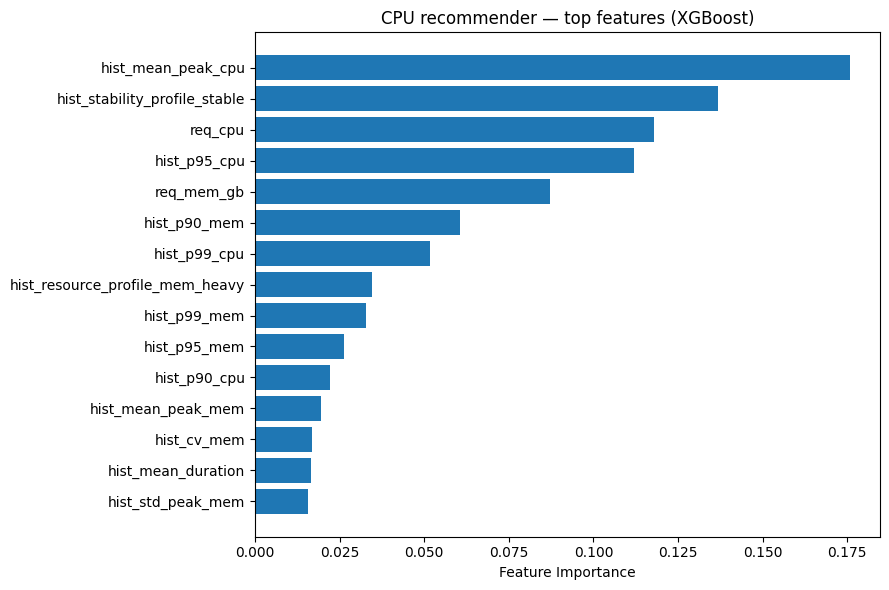

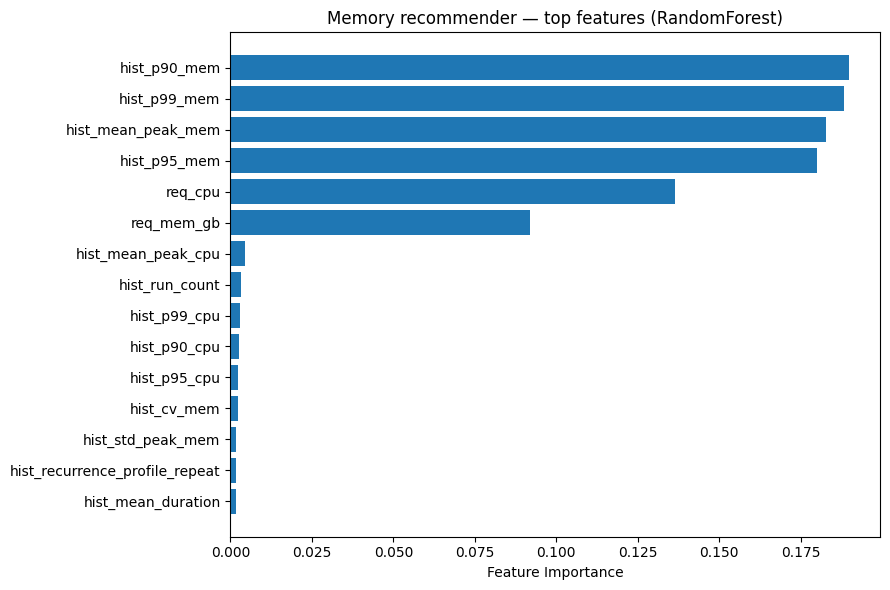

CPU feature importance:


,feature,importance
5,hist_mean_peak_cpu,0.175878
35,hist_stability_profile_stable,0.136793
0,req_cpu,0.117951
9,hist_p95_cpu,0.111999
1,req_mem_gb,0.087281
14,hist_p90_mem,0.060594
10,hist_p99_cpu,0.051743
23,hist_resource_profile_mem_heavy,0.034631
16,hist_p99_mem,0.032894
15,hist_p95_mem,0.026185


Memory feature importance:


,feature,importance
14,hist_p90_mem,0.189824
16,hist_p99_mem,0.188247
11,hist_mean_peak_mem,0.182875
15,hist_p95_mem,0.180016
0,req_cpu,0.136496
1,req_mem_gb,0.091976
5,hist_mean_peak_cpu,0.004395
2,hist_run_count,0.003390
10,hist_p99_cpu,0.003005
8,hist_p90_cpu,0.002743


In [8]:
def plot_importance(model, feature_names, title, save_path, top_n=15):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    top = importance_df.head(top_n).sort_values("importance")

    plt.figure(figsize=(9, 6))
    plt.barh(top["feature"], top["importance"])
    plt.xlabel("Feature Importance")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

    return importance_df.head(top_n)

cpu_imp = plot_importance(
    final_cpu_model,
    X_train_cpu.columns,
    f"CPU recommender — top features ({cpu_pick['model']})",
    FIG_ML_DIR / "feature_importance_cpu.png",
)

mem_imp = plot_importance(
    final_mem_model,
    X_train_mem.columns,
    f"Memory recommender — top features ({mem_pick['model']})",
    FIG_ML_DIR / "feature_importance_mem.png",
)

print("CPU feature importance:")
display(cpu_imp)

print("Memory feature importance:")
display(mem_imp)

## 7. Developer-facing recommendation simulation

This is the deployment-style output. Given a single job's metadata + recent
history, TraceAdvisor produces:

- a **recommended CPU** and **recommended memory**, taken as the safer of
  the ML forecast and a conservative historical safeguard (`p95`),
- a **confidence tier** derived from how stable the job's history is
  (run count + coefficient of variation),
- an **expected violation risk** label, computed from the gap between the
  recommendation and the historical p95.

The same logic is applied row-by-row to the test split so we can also report
aggregate CPU/memory violation and waste numbers.


In [9]:
def safe_col(df, col, default=np.nan):
    return df[col] if col in df.columns else pd.Series(default, index=df.index)


def confidence_tier(run_count, stability):
    """Confidence based on history depth and overall workload stability."""
    rc = 0 if pd.isna(run_count) else float(run_count)
    s = float("inf") if pd.isna(stability) else float(stability)

    if rc >= 30 and s < 0.50:
        return "high"
    if rc >= 30:
        return "medium"
    if rc >= 10 and s < 0.75:
        return "medium"
    return "low"


def violation_risk(rec, p95, p99):
    """Risk that the next run exceeds the recommendation.

    Anchored on p95 because the hybrid recommendation is
    max(ML prediction, historical P95).
    """
    if pd.isna(rec) or rec == 0:
        return "Unknown"
    if pd.isna(p95) or p95 <= 0:
        return "Unknown"

    margin = (rec - p95) / p95

    if margin >= 0.10:
        return "Low"
    if margin >= 0.0:
        return "Medium"
    return "High"


def recommend_for_split(df, X_cpu, X_mem):
    out = df.copy()

    # ML predictions
    out["ml_pred_cpu"] = final_cpu_model.predict(X_cpu)
    out["ml_pred_mem_gb"] = final_mem_model.predict(X_mem)

    # Historical P95/P99 values
    p95_cpu = safe_col(out, "hist_p95_cpu")
    p99_cpu = safe_col(out, "hist_p99_cpu")
    p95_mem = safe_col(out, "hist_p95_mem")
    p99_mem = safe_col(out, "hist_p99_mem")

    # Hybrid recommendation = max(ML prediction, historical P95)
    # If no historical P95 exists, fall back to ML.
    out["rec_cpu"] = np.maximum(
        out["ml_pred_cpu"],
        p95_cpu.fillna(out["ml_pred_cpu"])
    )

    out["rec_mem_gb"] = np.maximum(
        out["ml_pred_mem_gb"],
        p95_mem.fillna(out["ml_pred_mem_gb"])
    )

    out["rec_cpu"] = out["rec_cpu"].clip(lower=0)
    out["rec_mem_gb"] = out["rec_mem_gb"].clip(lower=0)

    # Use the same stability/confidence definition as Notebook 4.
    run_count = safe_col(out, "hist_run_count", 0)
    stability = safe_col(out, "hist_stability")

    out["confidence"] = [
        confidence_tier(rc, s)
        for rc, s in zip(run_count, stability)
    ]

    # Violation-risk labels remain resource-specific.
    out["violation_risk_cpu"] = [
        violation_risk(r, p95, p99)
        for r, p95, p99 in zip(
            out["rec_cpu"],
            p95_cpu,
            p99_cpu
        )
    ]

    out["violation_risk_mem"] = [
        violation_risk(r, p95, p99)
        for r, p95, p99 in zip(
            out["rec_mem_gb"],
            p95_mem,
            p99_mem
        )
    ]

    return out


test_recs = recommend_for_split(
    test_df,
    X_test_cpu,
    X_test_mem
)

display(
    test_recs[[
        "recurrence_key",
        "hist_run_count",
        "hist_stability",
        "req_cpu",
        "rec_cpu",
        "peak_cpu",
        "req_mem_gb",
        "rec_mem_gb",
        "peak_mem_gb",
        "confidence",
        "violation_risk_cpu",
        "violation_risk_mem",
    ]].head(10)
)

,recurrence_key,hist_run_count,hist_stability,req_cpu,rec_cpu,peak_cpu,req_mem_gb,rec_mem_gb,peak_mem_gb,confidence,violation_risk_cpu,violation_risk_mem
0,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,959,2.346038,0.008102,0.007215,0.000818,0.003613,0.0007,0.000679,medium,Low,Medium
1,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,959,2.346038,0.008102,0.007215,0.000818,0.003613,0.0007,0.000679,medium,Low,Medium
2,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,959,2.346038,0.008102,0.007215,0.000818,0.003613,0.0007,0.000679,medium,Low,Medium
3,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,959,2.346038,0.008102,0.007215,0.000818,0.003613,0.0007,0.000679,medium,Low,Medium
4,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,959,2.346038,0.008102,0.007215,0.000818,0.003613,0.0007,0.000679,medium,Low,Medium
5,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,959,2.346038,0.008102,0.007215,0.000818,0.003613,0.0007,0.000679,medium,Low,Medium
6,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,959,2.346038,0.008102,0.007215,0.000818,0.003613,0.0007,0.000679,medium,Low,Medium
7,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,959,2.346038,0.008102,0.007215,0.000818,0.003613,0.0007,0.000679,medium,Low,Medium
8,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,959,2.346038,0.008102,0.007215,0.000818,0.003613,0.0007,0.000679,medium,Low,Medium
9,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,959,2.346038,0.008102,0.007215,0.000818,0.003613,0.0007,0.000679,medium,Low,Medium


In [10]:
def policy_metrics(df, actual_col, rec_col):
    tmp = df[[actual_col, rec_col]].dropna()
    if len(tmp) == 0:
        return {}
    actual = tmp[actual_col]
    rec = tmp[rec_col]
    slack = rec - actual
    return {
        "rows": len(tmp),
        "violation_rate": float((actual > rec).mean()),
        "coverage":       float((actual <= rec).mean()),
        "avg_slack":      float(slack.mean()),
        "avg_overprovision":  float(slack.clip(lower=0).mean()),
        "avg_underprovision": float((-slack).clip(lower=0).mean()),
        "mae":            float(slack.abs().mean()),
    }


final_summary = pd.DataFrame([
    {"resource": "cpu", **policy_metrics(test_recs, "peak_cpu", "rec_cpu")},
    {"resource": "mem", **policy_metrics(test_recs, "peak_mem_gb", "rec_mem_gb")},
    # for reference: as-is
    {"resource": "cpu_as_is", **policy_metrics(test_recs, "peak_cpu", "req_cpu")},
    {"resource": "mem_as_is", **policy_metrics(test_recs, "peak_mem_gb", "req_mem_gb")},
])
final_summary.to_csv(TABLE_DIR / "final_recommender_test_v0.csv", index=False, float_format="%.6f")
display(final_summary)


,resource,rows,violation_rate,coverage,avg_slack,avg_overprovision,avg_underprovision,mae
0,cpu,10762,0.140773,0.859227,0.016724,0.021116,0.004391,0.025507
1,mem,10762,0.159729,0.840271,0.002329,0.002531,0.000202,0.002733
2,cpu_as_is,10762,0.436908,0.563092,-0.007372,0.005289,0.012661,0.017950
3,mem_as_is,10762,0.105092,0.894908,0.011032,0.012018,0.000986,0.013004


### 7a. Worked example — what a developer would see

Pick one row from the test split with enough history and render the
recommendation the way it would appear in the TraceAdvisor CLI / UI.


In [11]:
def render_recommendation(row):
    based_on = int(row.get("hist_run_count", 0) or 0)
    key = str(row.get("recurrence_key", "<unknown>"))
    key_short = (key[:32] + "…") if len(key) > 33 else key

    return (
        f"TraceAdvisor recommendation for job: {key_short}\n"
        f"  Recommended CPU   : {row['rec_cpu']:.4f}    "
        f"(historical p95 = {row.get('hist_p95_cpu', float('nan')):.4f})\n"
        f"  Recommended Memory: {row['rec_mem_gb']:.4f} GB "
        f"(historical p95 = {row.get('hist_p95_mem', float('nan')):.4f} GB)\n"
        f"  Confidence        : {row['confidence']}\n"
        f"  Expected violation risk (CPU/Mem): "
        f"{row['violation_risk_cpu']} / {row['violation_risk_mem']}\n"
        f"  Based on: {based_on} prior runs"
    )


# Pick one row per distinct recurring job, then sample one.
candidates = test_recs[test_recs["hist_run_count"].fillna(0) >= 5]

if len(candidates):
    demo_row = (
        candidates
        .drop_duplicates("recurrence_key")
        .sample(1, random_state=42)
        .iloc[0]
    )
else:
    demo_row = test_recs.iloc[0]

print(render_recommendation(demo_row))

TraceAdvisor recommendation for job: CwGnjPqF6z6mEbr5zJVXafRsbETt6gvd…
  Recommended CPU   : 0.1088    (historical p95 = 0.1088)
  Recommended Memory: 0.0411 GB (historical p95 = 0.0411 GB)
  Confidence        : high
  Expected violation risk (CPU/Mem): Medium / Medium
  Based on: 34 prior runs


## 7b. Paper-style CPU metrics — ML Only vs Hybrid

CPU-only summary of the final test-set recommendations:

- **Safety (%)** — share of jobs where the recommendation covered the realized peak.

- **Violation (%)** — share of jobs where actual peak CPU exceeded the recommendation. This is the complement of Safety.

- **Utilization capped (%)** — `mean(min(actual / recommended, 1)) × 100`. Measures how much of the recommended CPU was used while capping values at 100%.

- **Utilization median (%)** — `median(actual / recommended) × 100`. Provides a robust view of how tightly recommendations match actual CPU usage.

Higher utilization generally indicates tighter provisioning, but it should be considered together with Violation and Safety.

**ML Only** uses the raw regressor prediction. **Hybrid** is the final TraceAdvisor recommendation: `max(ML prediction, historical P95)`.

In [12]:
def table_metrics(actual, recommended):
    tmp = pd.DataFrame({"actual": actual, "recommended": recommended}).dropna()
    tmp = tmp[tmp["recommended"] > 0]
    if len(tmp) == 0:
        return float("nan"), float("nan"), float("nan"), float("nan")

    violation = (tmp["actual"] > tmp["recommended"]).mean() * 100
    safety = 100 - violation

    ratio = tmp["actual"] / tmp["recommended"]
    util_capped = ratio.clip(upper=1.0).mean() * 100   # bounded 0–100, "fully-used %"
    util_median = ratio.median() * 100                  # robust to outliers

    return safety, violation, util_capped, util_median


ml_safety, ml_violation, ml_util, ml_util_med = table_metrics(
    test_recs["peak_cpu"], test_recs["ml_pred_cpu"]
)
hybrid_safety, hybrid_violation, hybrid_util, hybrid_util_med = table_metrics(
    test_recs["peak_cpu"], test_recs["rec_cpu"]
)

traceadvisor_rows = pd.DataFrame([
    {
        "Workload": "TraceAdvisor",
        "Method": "ML Only",
        "Safety (%)": round(ml_safety, 1),
        "Violation (%)": round(ml_violation, 1),
        "Utilization capped (%)": round(ml_util, 1),
        "Utilization median (%)": round(ml_util_med, 1),
    },
    {
        "Workload": "TraceAdvisor",
        "Method": "Hybrid",
        "Safety (%)": round(hybrid_safety, 1),
        "Violation (%)": round(hybrid_violation, 1),
        "Utilization capped (%)": round(hybrid_util, 1),
        "Utilization median (%)": round(hybrid_util_med, 1),
    },
])

traceadvisor_rows.to_csv(
    TABLE_DIR / "traceadvisor_cpu_metrics_v0.csv", index=False
)
display(traceadvisor_rows)

,Workload,Method,Safety (%),Violation (%),Utilization capped (%),Utilization median (%)
0,TraceAdvisor,ML Only,69.9,30.1,52.2,47.2
1,TraceAdvisor,Hybrid,85.9,14.1,42.3,31.6


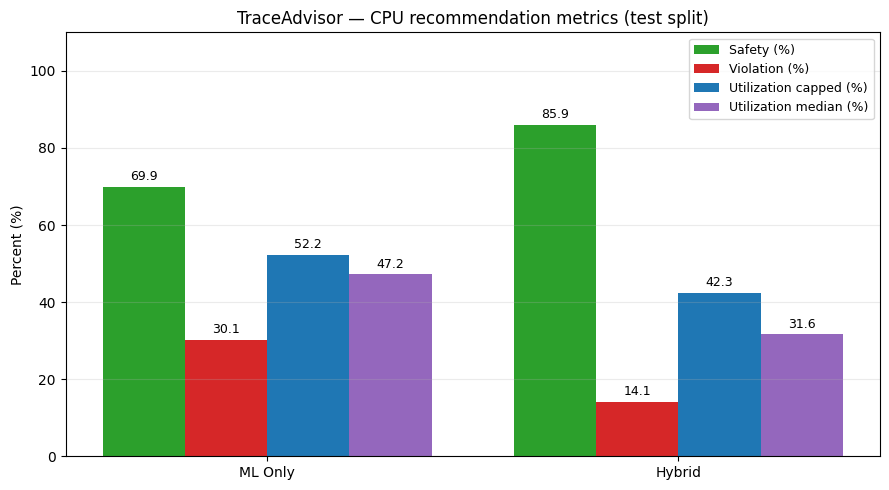

Saved: /Users/sofiasilva/Masters-project/masters-project/reports/eval/subset/figures_ml/traceadvisor_cpu_metrics.png


In [13]:
methods = traceadvisor_rows["Method"].tolist()
metrics = ["Safety (%)", "Violation (%)", "Utilization capped (%)", "Utilization median (%)"]

x = np.arange(len(methods))
width = 0.2
colors = ["#2ca02c", "#d62728", "#1f77b4", "#9467bd"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = traceadvisor_rows[metric].tolist()
    bars = ax.bar(x + (i - 1.5) * width, vals, width, label=metric, color=color)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
                f"{v:.1f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Percent (%)")
ax.set_ylim(0, 110)
ax.set_title("TraceAdvisor — CPU recommendation metrics (test split)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.25)

out_chart = FIG_ML_DIR / "traceadvisor_cpu_metrics.png"
plt.tight_layout()
plt.savefig(out_chart, dpi=200, bbox_inches="tight")
plt.show()
plt.close()
print("Saved:", out_chart)

## 8. Persist final recommendations


In [14]:
out_path = DATA_PROCESSED / "job_metrics_test_with_final_recommendations_v0.parquet"

# Save final test recommendations
test_recs.to_parquet(out_path, index=False)

print("Final outputs:")
print("Wrote:", out_path)
print("Created earlier:", TABLE_DIR / "ml_tuning_summary_v0.csv")
print("Created earlier:", TABLE_DIR / "ml_cv_summary_v0.csv")
print("Created earlier:", TABLE_DIR / "final_recommender_test_v0.csv")
print("Created earlier:", FIG_ML_DIR / "feature_importance_cpu.png")
print("Created earlier:", FIG_ML_DIR / "feature_importance_mem.png")
print("Created earlier:", FIG_ML_DIR / "traceadvisor_cpu_metrics.png")

Final outputs:
Wrote: /Users/sofiasilva/Masters-project/masters-project/data/processed/job_metrics_test_with_final_recommendations_v0.parquet
Created earlier: /Users/sofiasilva/Masters-project/masters-project/reports/eval/subset/tables/ml_tuning_summary_v0.csv
Created earlier: /Users/sofiasilva/Masters-project/masters-project/reports/eval/subset/tables/ml_cv_summary_v0.csv
Created earlier: /Users/sofiasilva/Masters-project/masters-project/reports/eval/subset/tables/final_recommender_test_v0.csv
Created earlier: /Users/sofiasilva/Masters-project/masters-project/reports/eval/subset/figures_ml/feature_importance_cpu.png
Created earlier: /Users/sofiasilva/Masters-project/masters-project/reports/eval/subset/figures_ml/feature_importance_mem.png
Created earlier: /Users/sofiasilva/Masters-project/masters-project/reports/eval/subset/figures_ml/traceadvisor_cpu_metrics.png


## 9. Conclusions

- **Model tuning** compares Random Forest and XGBoost for both CPU and memory, with final model selection based on validation RMSE.

- **Cross-validation** uses both `TimeSeriesSplit` and `GroupKFold` as complementary diagnostics: temporal performance on later executions and generalization across recurrence groups.

- **Point-in-time historical features** ensure that each recommendation uses only information available before the current execution begins, preventing future-information leakage.

- **Final model lock-in** selects the best validated model for each resource before evaluating the untouched test split.

- **Hybrid recommendations** combine the ML prediction with a historical safeguard using `max(ML prediction, historical P95)`.

- **Final test evaluation** reports Safety, Violation, and Utilization to measure the tradeoff between reliable resource coverage and efficient provisioning.

- **Developer-facing recommendations** provide CPU and memory recommendations together with workload-level confidence and resource-specific violation-risk labels.
